# CSE 144 Final Project: Dual-Backbone Frozen Feature Classification

**Task:** 100 class image classification, 10 training images per class.
**Strategy:** Extract features from two complementary frozen backbones: DINOv2 ViT-L/14 (self supervised, state of the art frozen features) and SWAG ViT-B/16 (weakly supervised): concatenate them, and train an ensemble of regularized linear heads on the cached features.

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ViT_B_16_Weights
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import copy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


## 2. Configuration

In [2]:
TRAIN_DIR = 'ucsc-cse-144-spring-2026-final-project/train'
TEST_DIR = 'ucsc-cse-144-spring-2026-final-project/test'
MODEL_SAVE_PATH = 'best_vit_model.pth'

NUM_CLASSES = 100
EXTRACT_BATCH = 16

USE_DINO = True
USE_SWAG = True

DINO_SIZE = 224
SWAG_SIZE = 384

TRAIN_VIEWS = 4
TEST_VIEWS = 2

HEAD_EPOCHS = 60
HEAD_LR = 1e-3
HEAD_WD = 1e-3
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1
VAL_SPLIT = 0.15
HEAD_BATCH = 128
N_ENSEMBLE = 5

## 3. Dataset Classes

In [3]:
class TrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        class_names = [d for d in os.listdir(root_dir) if not d.startswith('.') and os.path.isdir(os.path.join(root_dir, d))]
        class_names.sort(key=int)
        for class_name in class_names:
            class_dir = os.path.join(root_dir, class_name)
            label = int(class_name)
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, img_file), label))
        print(f'Loaded {len(self.samples)} training images across {len(class_names)} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_files = sorted(
            [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        print(f'Loaded {len(self.image_files)} test images')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

## 4. Frozen Backbones

DINOv2 ViT-L/14 produces 1024 dim self supervised features that are state of the art for linear probing. SWAG ViT-B/16 adds a complementary 768 dim weakly supervised view. Both stay frozen and in eval mode throughout.

In [4]:
backbones = {}

if USE_DINO:
    dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
    for p in dino.parameters():
        p.requires_grad = False
    dino = dino.to(device).eval()
    backbones['dino'] = (dino, 1024, DINO_SIZE)
    print('DINOv2 ViT-L/14 loaded (1024-dim).')

if USE_SWAG:
    swag = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1)
    swag.heads = nn.Identity()
    for p in swag.parameters():
        p.requires_grad = False
    swag = swag.to(device).eval()
    backbones['swag'] = (swag, 768, SWAG_SIZE)
    print('SWAG ViT-B/16 loaded (768-dim).')

FEAT_DIM = sum(d for _, d, _ in backbones.values())
print(f'Combined feature dim: {FEAT_DIM}')

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /Users/satvik/.cache/torch/hub/main.zip


/Users/satvik/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/satvik/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/satvik/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /Users/satvik/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:10<00:00, 111MB/s] 


DINOv2 ViT-L/14 loaded (1024-dim).
SWAG ViT-B/16 loaded (768-dim).
Combined feature dim: 1792


## 5. Feature Extraction

For each backbone, every image is encoded under several views (center crop, flip, random crops at that backbone's native resolution). Per backbone features for the same view index are concatenated into a single vector.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def make_view_transforms(img_size):
    center = T.Compose([
        T.Resize(int(img_size * 1.05), interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(img_size),
        T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    flip = T.Compose([
        T.Resize(int(img_size * 1.05), interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(img_size), T.RandomHorizontalFlip(p=1.0),
        T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    crop = T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    return [center, flip, crop, crop]

@torch.no_grad()
def extract(model, dataset_cls, root, transform, is_test=False):
    ds = dataset_cls(root, transform=transform)
    dl = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False, num_workers=0)
    feats, metas = [], []
    for images, meta in dl:
        f = model(images.to(device))
        feats.append(f.cpu())
        if is_test:
            metas.extend(list(meta))
        else:
            metas.append(meta)
    feats = torch.cat(feats)
    if not is_test:
        metas = torch.cat(metas)
    return feats, metas

def extract_views(dataset_cls, root, n_views, is_test=False, seed_offset=0):
    per_view = []
    meta_out = None
    for v in range(n_views):
        parts = []
        for name, (model, dim, size) in backbones.items():
            torch.manual_seed(SEED + seed_offset + v)
            random.seed(SEED + seed_offset + v)
            np.random.seed(SEED + seed_offset + v)
            tf = make_view_transforms(size)[v % 4]
            f, meta = extract(model, dataset_cls, root, tf, is_test=is_test)
            parts.append(f)
            if meta_out is None:
                meta_out = meta
        per_view.append(torch.cat(parts, dim=1))
        print(f'View {v+1}/{n_views} extracted: {per_view[-1].shape}')
    return per_view, meta_out

In [6]:
train_views, train_labels_single = extract_views(TrainDataset, TRAIN_DIR, TRAIN_VIEWS)
n_images = train_views[0].shape[0]
train_feats = torch.cat(train_views)
train_labels = train_labels_single.repeat(TRAIN_VIEWS)
print(f'Total cached training features: {train_feats.shape}')

Loaded 1079 training images across 100 classes
Loaded 1079 training images across 100 classes
View 1/4 extracted: torch.Size([1079, 1792])
Loaded 1079 training images across 100 classes
Loaded 1079 training images across 100 classes
View 2/4 extracted: torch.Size([1079, 1792])
Loaded 1079 training images across 100 classes
Loaded 1079 training images across 100 classes
View 3/4 extracted: torch.Size([1079, 1792])
Loaded 1079 training images across 100 classes
Loaded 1079 training images across 100 classes
View 4/4 extracted: torch.Size([1079, 1792])
Total cached training features: torch.Size([4316, 1792])


## 6. Train/Val Split

Image level split so augmented views of the same image never straddle the boundary.

In [7]:
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_images, generator=g)
val_size = int(n_images * VAL_SPLIT)
val_idx_img = perm[:val_size]
train_idx_img = perm[val_size:]

train_idx = torch.cat([train_idx_img + v * n_images for v in range(TRAIN_VIEWS)])
val_idx = val_idx_img

X_train, y_train = train_feats[train_idx], train_labels[train_idx]
X_val, y_val = train_feats[val_idx], train_labels[val_idx]
print(f'Head training set: {X_train.shape[0]} vectors | Val: {X_val.shape[0]} vectors')

Head training set: 3672 vectors | Val: 161 vectors


### Feature Standardization

Per dimension standardization computed on the training split, which also balances the scales of the two concatenated backbones.

In [8]:
feat_mean = X_train.mean(dim=0, keepdim=True)
feat_std = X_train.std(dim=0, keepdim=True) + 1e-6

X_train = (X_train - feat_mean) / feat_std
X_val = (X_val - feat_mean) / feat_std
train_feats_norm = (train_feats - feat_mean) / feat_std
print('Features standardized using training statistics.')

Features standardized using training statistics.


## 7. Validation Run

A single head is trained with a validation split to verify the recipe and produce training curves.

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(FEAT_DIM, NUM_CLASSES)).to(device)
optimizer = optim.AdamW(head.parameters(), lr=HEAD_LR, weight_decay=HEAD_WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HEAD_EPOCHS, eta_min=1e-5)

train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=HEAD_BATCH, shuffle=True)
X_val_d, y_val_d = X_val.to(device), y_val.to(device)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc, best_state = 0.0, None

for epoch in range(HEAD_EPOCHS):
    head.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        out = head(xb)
        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += out.argmax(1).eq(yb).sum().item()
        total += yb.size(0)
    cur_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    head.eval()
    with torch.no_grad():
        val_out = head(X_val_d)
        val_loss = criterion(val_out, y_val_d).item()
        val_acc = 100.0 * val_out.argmax(1).eq(y_val_d).float().mean().item()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','lr'],
                    [train_loss, val_loss, train_acc, val_acc, cur_lr]):
        history[k].append(v)

    tag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(head.state_dict())
        tag = ' *BEST*'
    if (epoch + 1) % 5 == 0 or tag:
        print(f'Epoch [{epoch+1:2d}/{HEAD_EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}%{tag}')

print(f'\nBest val accuracy: {best_val_acc:.1f}%')

Epoch [ 1/60] Train Loss: 1.9515 Acc: 69.4% | Val Loss: 1.4466 Acc: 77.0% *BEST*
Epoch [ 2/60] Train Loss: 1.0824 Acc: 95.3% | Val Loss: 1.2836 Acc: 83.9% *BEST*
Epoch [ 5/60] Train Loss: 0.8613 Acc: 99.6% | Val Loss: 1.2954 Acc: 82.6%
Epoch [ 6/60] Train Loss: 0.8491 Acc: 99.9% | Val Loss: 1.2815 Acc: 85.1% *BEST*
Epoch [10/60] Train Loss: 0.8309 Acc: 100.0% | Val Loss: 1.3003 Acc: 83.2%
Epoch [15/60] Train Loss: 0.8210 Acc: 100.0% | Val Loss: 1.3114 Acc: 87.0% *BEST*
Epoch [20/60] Train Loss: 0.8164 Acc: 100.0% | Val Loss: 1.3262 Acc: 83.9%
Epoch [25/60] Train Loss: 0.8138 Acc: 100.0% | Val Loss: 1.3527 Acc: 82.0%
Epoch [30/60] Train Loss: 0.8106 Acc: 100.0% | Val Loss: 1.3332 Acc: 83.9%
Epoch [35/60] Train Loss: 0.8093 Acc: 100.0% | Val Loss: 1.3535 Acc: 83.2%
Epoch [40/60] Train Loss: 0.8069 Acc: 100.0% | Val Loss: 1.3357 Acc: 83.9%
Epoch [45/60] Train Loss: 0.8053 Acc: 100.0% | Val Loss: 1.3349 Acc: 84.5%
Epoch [50/60] Train Loss: 0.8052 Acc: 100.0% | Val Loss: 1.3377 Acc: 83.2%
E

## 8. Plot Training Curves

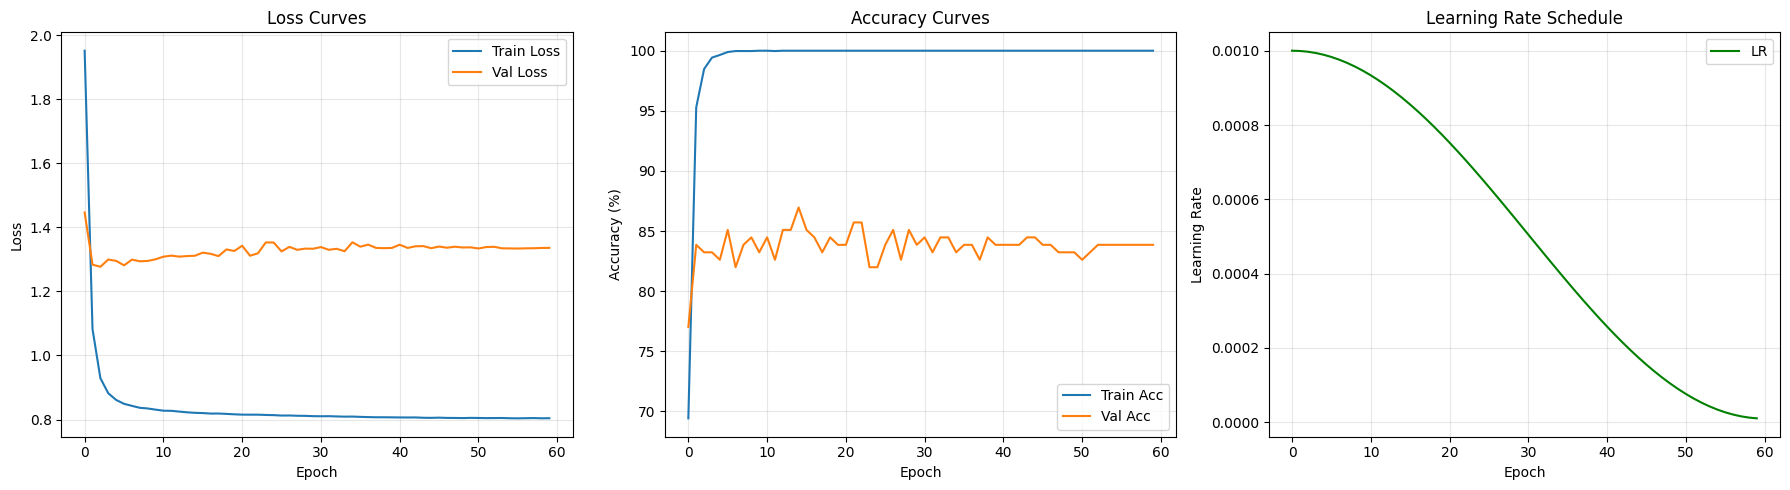

Saved training_curves.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss Curves')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green', label='LR')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate'); axes[2].set_title('Learning Rate Schedule')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 9. Final Ensemble: Retrain on ALL Data

Five heads with different seeds are trained on every cached feature vector; their softmax outputs are averaged at inference.

In [11]:
heads_final = []
full_ds = TensorDataset(train_feats_norm, train_labels)

for k in range(N_ENSEMBLE):
    torch.manual_seed(SEED + k)
    h = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(FEAT_DIM, NUM_CLASSES)).to(device)
    opt = optim.AdamW(h.parameters(), lr=HEAD_LR, weight_decay=HEAD_WD)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=HEAD_EPOCHS, eta_min=1e-5)
    dl = DataLoader(full_ds, batch_size=HEAD_BATCH, shuffle=True, generator=torch.Generator().manual_seed(SEED + k))

    for epoch in range(HEAD_EPOCHS):
        h.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(h(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        sch.step()
    h.eval()
    heads_final.append(h)
    print(f'Ensemble head {k+1}/{N_ENSEMBLE} trained.')

torch.save({f'head_{k}': h.state_dict() for k, h in enumerate(heads_final)}, MODEL_SAVE_PATH)
print(f'Ensemble of {N_ENSEMBLE} heads saved to {MODEL_SAVE_PATH}')

Ensemble head 1/5 trained.
Ensemble head 2/5 trained.
Ensemble head 3/5 trained.
Ensemble head 4/5 trained.
Ensemble head 5/5 trained.
Ensemble of 5 heads saved to best_vit_model.pth


## 10. Test Predictions with TTA

Test features are extracted under center crop and flipped views for each backbone, standardized with the training statistics, and scored by the averaged ensemble.

In [12]:
test_views, test_fnames = extract_views(TestDataset, TEST_DIR, TEST_VIEWS, is_test=True, seed_offset=100)

all_probs = None
for v, feats in enumerate(test_views):
    feats = ((feats - feat_mean) / feat_std).to(device)
    with torch.no_grad():
        probs = torch.zeros(feats.shape[0], NUM_CLASSES)
        for h in heads_final:
            probs += torch.softmax(h(feats), dim=1).cpu()
    all_probs = probs if all_probs is None else all_probs + probs
    print(f'TTA view {v+1}/{len(test_views)} scored.')

predictions = {fname: int(all_probs[i].argmax()) for i, fname in enumerate(test_fnames)}
print(f'\nGenerated predictions for {len(predictions)} test images.')

Loaded 1036 test images
Loaded 1036 test images
View 1/2 extracted: torch.Size([1036, 1792])
Loaded 1036 test images
Loaded 1036 test images
View 2/2 extracted: torch.Size([1036, 1792])
TTA view 1/2 scored.
TTA view 2/2 scored.

Generated predictions for 1036 test images.


In [13]:
rows = [{'ID': fname, 'Label': label} for fname, label in predictions.items()]
submission_df = pd.DataFrame(rows)
submission_df['_sort'] = submission_df['ID'].apply(lambda x: int(os.path.splitext(x)[0]))
submission_df = submission_df.sort_values('_sort').drop(columns='_sort').reset_index(drop=True)

submission_df.to_csv('submission.csv', index=False)
print(f'Saved submission.csv with {len(submission_df)} rows')
print(submission_df.head(10))

Saved submission.csv with 1036 rows
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     71
9  9.jpg     65


---
## Summary

| Component | Choice | Rationale |
|-----------|--------|----------|
| **Backbones** | DINOv2 ViT-L/14 (frozen) + SWAG ViT-B/16 (frozen) | DINOv2 features are state of the art for linear probing; SWAG adds a complementary supervised signal |
| **Feature dim** | 1024 + 768 = 1792 (concatenated) | Two independent views of each image |
| **Feature caching** | 4 augmented views per training image | Multiplies effective training data at zero backprop cost |
| **Normalization** | Per-dimension standardization from train stats | Balances scales across backbones |
| **Head** | Dropout(0.3) - Linear(1792, 100), 5-seed ensemble | Tiny trainable parameter count resists few-shot overfitting |
| **Loss** | CrossEntropy + label smoothing (0.1) | Prevents overconfident predictions |
| **Validation** | 15% image-level split | Views of the same image never straddle the split |
| **Inference** | 2-view TTA x 5-head ensemble, softmax-averaged | Center crop + horizontal flip per backbone |